  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl (12.3 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.5 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp313-c


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


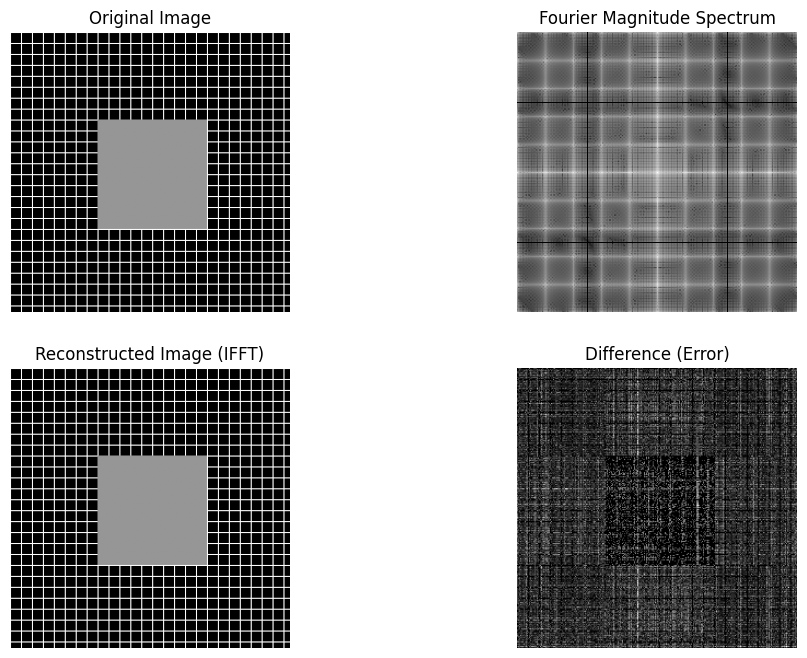

In [5]:
# Import libraries
!pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a synthetic image (simple pattern)
def create_synthetic_image(size=256):
    img = np.zeros((size, size))

    # Add horizontal and vertical stripes
    img[::10, :] = 255
    img[:, ::10] = 255

    # Add a square in the center
    img[80:180, 80:180] = 150

    return img

image = create_synthetic_image()

# Step 2: Apply Fourier Transform
fft = np.fft.fft2(image)
fft_shift = np.fft.fftshift(fft)  # Shift zero frequency to center

# Magnitude spectrum (log for visibility)
magnitude_spectrum = np.log(1 + np.abs(fft_shift))

# Step 3: Apply Inverse Fourier Transform
ifft_shift = np.fft.ifftshift(fft_shift)
reconstructed = np.fft.ifft2(ifft_shift)
reconstructed = np.abs(reconstructed)

# Step 4: Plot results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Fourier Magnitude Spectrum")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed Image (IFFT)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(np.abs(image - reconstructed), cmap='gray')
plt.title("Difference (Error)")
plt.axis('off')

plt.show()

In [ ]:
# Install (only needed in Colab)
!pip install opencv-python-headless

import numpy as np
import cv2
import matplotlib.pyplot as plt

Saving diplab4.jpg to diplab4.jpg


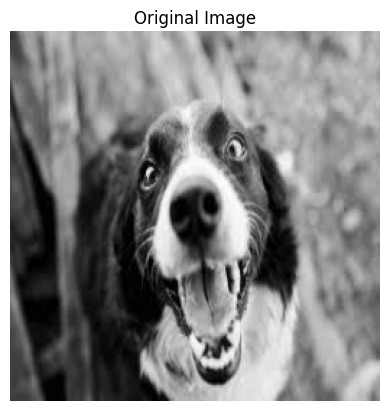

In [ ]:
# Load sample image (you can replace with your own)
from google.colab import files

uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]

img = cv2.imread(filename, 0)  # grayscale
img = cv2.resize(img, (256, 256))

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

In [ ]:
def fft_image(image):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    return fshift

def ifft_image(fshift):
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

In [ ]:
def ideal_lpf(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            if D <= D0:
                mask[i, j] = 1
    return mask

In [ ]:
def butterworth_lpf(shape, D0, n=2):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            mask[i, j] = 1 / (1 + (D/D0)**(2*n))
    return mask

In [ ]:
def gaussian_lpf(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            mask[i, j] = np.exp(-(D**2)/(2*(D0**2)))
    return mask

In [ ]:
def apply_filter(image, filter_mask):
    fshift = fft_image(image)
    filtered = fshift * filter_mask
    result = ifft_image(filtered)
    return result

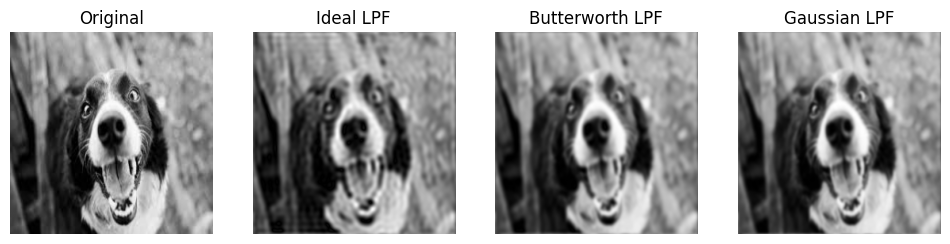

In [ ]:
D0 = 30

ideal = apply_filter(img, ideal_lpf(img.shape, D0))
butter = apply_filter(img, butterworth_lpf(img.shape, D0))
gaussian = apply_filter(img, gaussian_lpf(img.shape, D0))

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(ideal, cmap='gray')
plt.title("Ideal LPF")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(butter, cmap='gray')
plt.title("Butterworth LPF")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian LPF")
plt.axis('off')

plt.show()

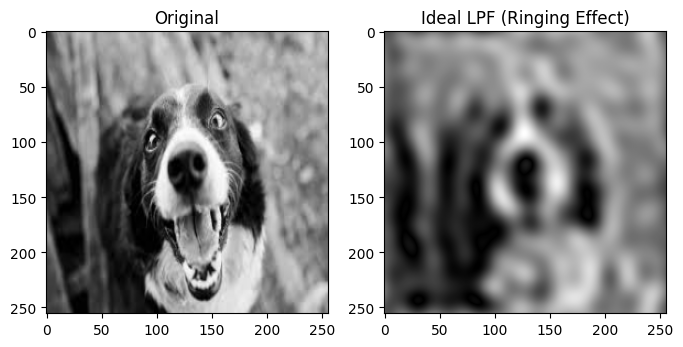

In [ ]:
D0 = 10  # small cutoff → more ringing

ideal_ringing = apply_filter(img, ideal_lpf(img.shape, D0))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(ideal_ringing, cmap='gray')
plt.title("Ideal LPF (Ringing Effect)")

plt.show()

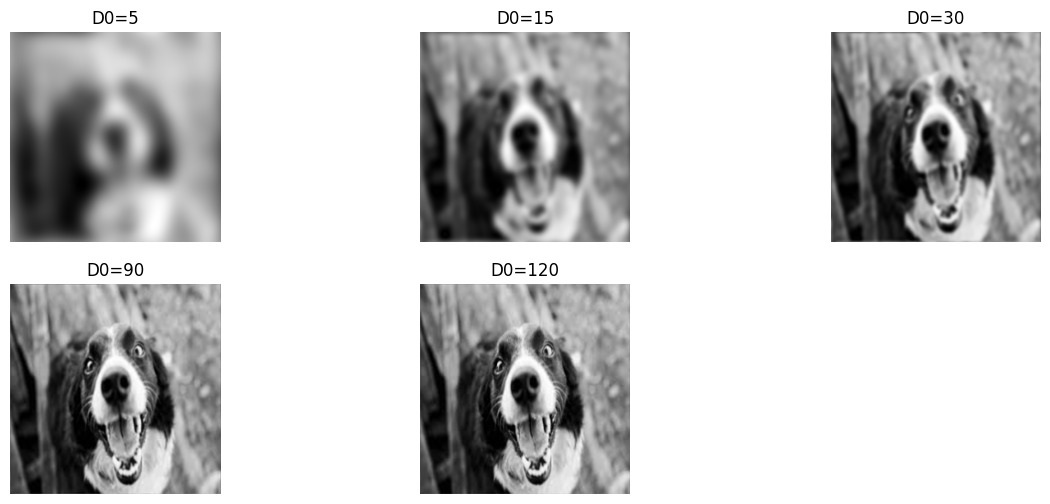

In [ ]:
cutoffs = [5, 15, 30, 90, 120]

plt.figure(figsize=(15,6))

for i, D0 in enumerate(cutoffs):
    result = apply_filter(img, butterworth_lpf(img.shape, D0, n=2))

    plt.subplot(2,3,i+1)
    plt.imshow(result, cmap='gray')
    plt.title(f"D0={D0}")
    plt.axis('off')

plt.show()

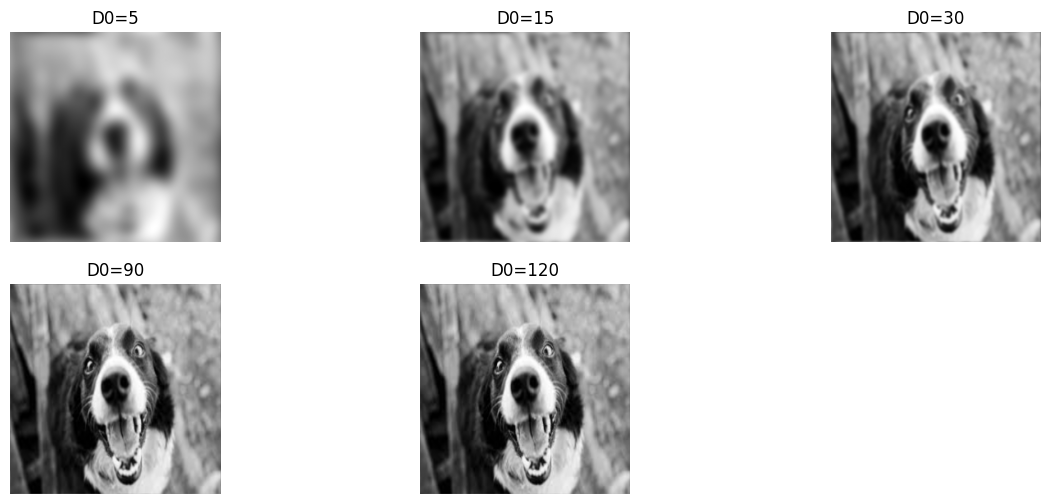

In [ ]:
plt.figure(figsize=(15,6))

for i, D0 in enumerate(cutoffs):
    result = apply_filter(img, gaussian_lpf(img.shape, D0))

    plt.subplot(2,3,i+1)
    plt.imshow(result, cmap='gray')
    plt.title(f"D0={D0}")
    plt.axis('off')

plt.show()

Saving diplab4.jpg to diplab4 (1).jpg


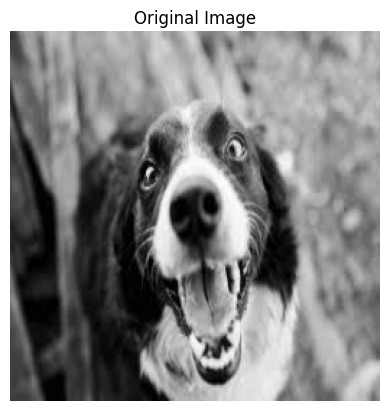

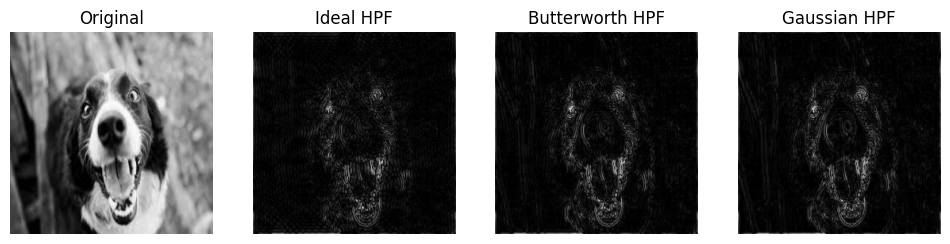

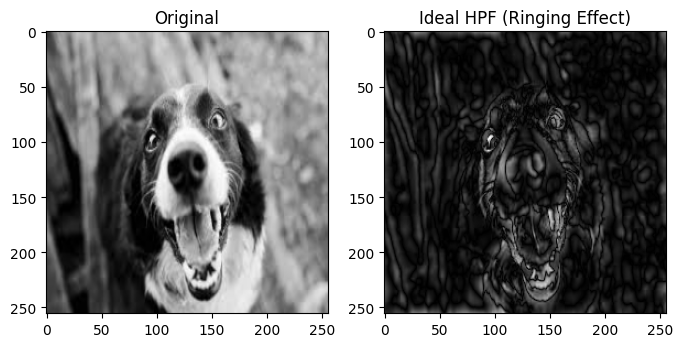

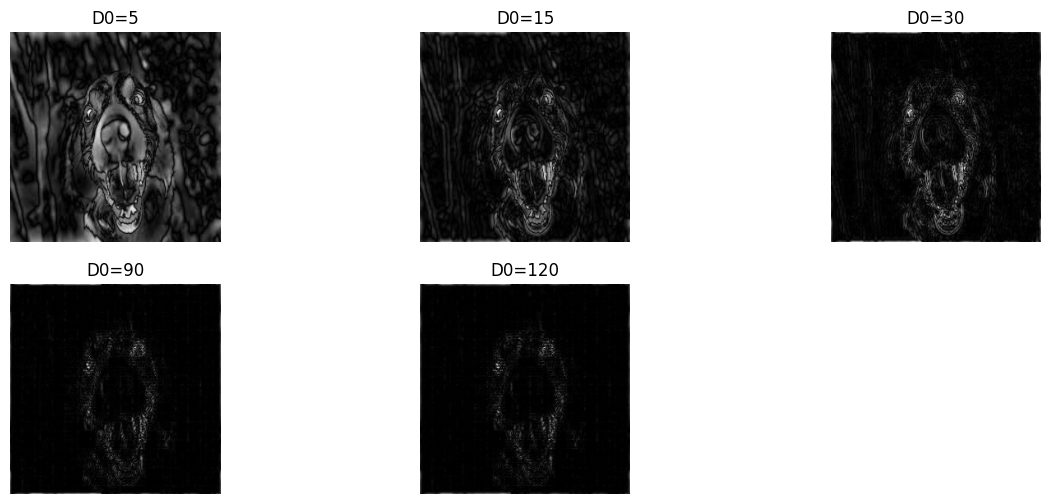

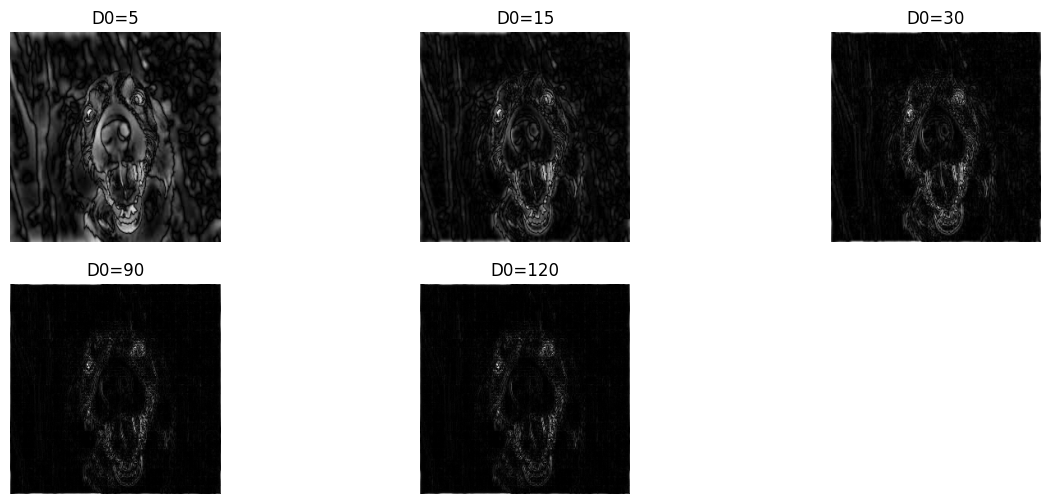

In [ ]:
# ================================
# 📦 Install & Import Libraries
# ================================
!pip install opencv-python-headless

import numpy as np
import cv2
import matplotlib.pyplot as plt

# ================================
# 🖼️ Load Image
# ================================
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename, 0)   # grayscale
img = cv2.resize(img, (256, 256))

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# ================================
# ⚙️ FFT Functions
# ================================
def fft_image(image):
    f = np.fft.fft2(image)
    return np.fft.fftshift(f)

def ifft_image(fshift):
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

# ================================
# 🎯 HIGH PASS FILTERS
# ================================

# 🔹 Ideal High Pass Filter
def ideal_hpf(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.ones((rows, cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            if D <= D0:
                mask[i, j] = 0
    return mask

# 🔹 Butterworth High Pass Filter
def butterworth_hpf(shape, D0, n=2):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            if D == 0:
                mask[i, j] = 0
            else:
                mask[i, j] = 1 / (1 + (D0/D)**(2*n))
    return mask

# 🔹 Gaussian High Pass Filter
def gaussian_hpf(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            mask[i, j] = 1 - np.exp(-(D**2)/(2*(D0**2)))
    return mask

# ================================
# 🔄 Apply Filter
# ================================
def apply_filter(image, filter_mask):
    fshift = fft_image(image)
    filtered = fshift * filter_mask
    result = ifft_image(filtered)
    return result

# ================================
# 📊 (a) Compare HPFs (same cutoff)
# ================================
D0 = 30

ideal = apply_filter(img, ideal_hpf(img.shape, D0))
butter = apply_filter(img, butterworth_hpf(img.shape, D0))
gaussian = apply_filter(img, gaussian_hpf(img.shape, D0))

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(ideal, cmap='gray')
plt.title("Ideal HPF")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(butter, cmap='gray')
plt.title("Butterworth HPF")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian HPF")
plt.axis('off')

plt.show()

# ================================
# 🔔 (b) Ringing Effect (Ideal HPF)
# ================================
D0 = 10

ringing = apply_filter(img, ideal_hpf(img.shape, D0))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(ringing, cmap='gray')
plt.title("Ideal HPF (Ringing Effect)")

plt.show()

# ================================
# 📈 (c) Butterworth HPF (n=2)
# ================================
cutoffs = [5, 15, 30, 90, 120]

plt.figure(figsize=(15,6))

for i, D0 in enumerate(cutoffs):
    result = apply_filter(img, butterworth_hpf(img.shape, D0, n=2))

    plt.subplot(2,3,i+1)
    plt.imshow(result, cmap='gray')
    plt.title(f"D0={D0}")
    plt.axis('off')

plt.show()

# ================================
# 📈 (d) Gaussian HPF
# ================================
plt.figure(figsize=(15,6))

for i, D0 in enumerate(cutoffs):
    result = apply_filter(img, gaussian_hpf(img.shape, D0))

    plt.subplot(2,3,i+1)
    plt.imshow(result, cmap='gray')
    plt.title(f"D0={D0}")
    plt.axis('off')

plt.show()